# 04 Statistical Analysis

Use this notebook for deeper analysis such as correlation checks, hypothesis testing, forecasting, segmentation, or regression.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, spearmanr, kruskal, mannwhitneyu, shapiro, f_oneway
import warnings
warnings.filterwarnings('ignore')

# ✅ Fix: use correct path relative to your project
import os
os.chdir(os.path.expanduser('~/SectionD_G12_BeijingPM25Analysis'))  # set working directory

df = pd.read_csv('data/processed/Beijing PM25 Data Cleaned.csv')  # adjust folder if needed
df['datetime'] = pd.to_datetime(df['datetime'])

df['rain_flag'] = df['hours_rain'].apply(lambda x: 'Rainy' if x > 0 else 'No Rain')
df['snow_flag'] = df['hours_snow'].apply(lambda x: 'Snowy' if x > 0 else 'No Snow')
df['season'] = df['month'].map({12:'Winter',1:'Winter',2:'Winter',
                                 3:'Spring',4:'Spring',5:'Spring',
                                 6:'Summer',7:'Summer',8:'Summer',
                                 9:'Autumn',10:'Autumn',11:'Autumn'})
df.head()

,datetime,year,month,day,hour,pm2_5,pm2_5_cleaned,dew_point,temperature,pressure,wind_direction,wind_speed,hours_snow,hours_rain,rain_flag,snow_flag,season
0,2010-01-01 00:00:00,2010,1,1,0,NaN,129.0,-21,-11.0,1021.0,NW,1.79,0,0,No Rain,No Snow,Winter
1,2010-01-01 01:00:00,2010,1,1,1,NaN,129.0,-21,-12.0,1020.0,NW,4.92,0,0,No Rain,No Snow,Winter
2,2010-01-01 02:00:00,2010,1,1,2,NaN,129.0,-21,-11.0,1019.0,NW,6.71,0,0,No Rain,No Snow,Winter
3,2010-01-01 03:00:00,2010,1,1,3,NaN,129.0,-21,-14.0,1019.0,NW,9.84,0,0,No Rain,No Snow,Winter
4,2010-01-01 04:00:00,2010,1,1,4,NaN,129.0,-20,-12.0,1018.0,NW,12.97,0,0,No Rain,No Snow,Winter


In [9]:
# Example placeholder for a statistical test.
# Replace with project-specific variables.
# test_stat, p_value = stats.ttest_ind(group_a, group_b, equal_var=False)
# print(test_stat, p_value)

In [10]:
# Record the business interpretation of each analysis directly below the code cell that produces it.

# Analysis 1 — Descriptive Statistics Summary

In [11]:
num_cols = ['pm2_5_cleaned', 'dew_point', 'temperature', 'pressure', 'wind_speed', 'hours_snow', 'hours_rain']

desc = df[num_cols].describe().T
desc['skewness'] = df[num_cols].skew()
desc['kurtosis'] = df[num_cols].kurt()
print(desc.round(3))

                 count      mean     std     min      25%      50%      75%  \
pm2_5_cleaned  43824.0    97.801  91.376    0.00    29.00    72.00   136.00   
dew_point      43824.0     1.817  14.433  -40.00   -10.00     2.00    15.00   
temperature    43824.0    12.449  12.199  -19.00     2.00    14.00    23.00   
pressure       43824.0  1016.448  10.269  991.00  1008.00  1016.00  1025.00   
wind_speed     43824.0    23.889  50.011    0.45     1.79     5.37    21.91   
hours_snow     43824.0     0.053   0.760    0.00     0.00     0.00     0.00   
hours_rain     43824.0     0.195   1.416    0.00     0.00     0.00     0.00   

                  max  skewness  kurtosis  
pm2_5_cleaned   994.0     1.823     5.035  
dew_point        28.0    -0.152    -1.195  
temperature      42.0    -0.163    -1.111  
pressure       1046.0     0.098    -0.846  
wind_speed      585.6     4.298    23.421  
hours_snow       27.0    19.484   449.082  
hours_rain       36.0    11.662   174.425  


# Analysis 2 — Normality Test (Shapiro-Wilk on sample)

In [12]:
# Shapiro-Wilk works best on samples ≤ 5000
sample = df['pm2_5_cleaned'].dropna().sample(2000, random_state=42)
stat, p = shapiro(sample)

print(f"Shapiro-Wilk Statistic: {stat:.4f}")
print(f"P-value: {p:.6f}")
print("Result:", "NOT Normal (use non-parametric tests)" if p < 0.05 else "Normal distribution")

Shapiro-Wilk Statistic: 0.8467
P-value: 0.000000
Result: NOT Normal (use non-parametric tests)


# Analysis 3 — Pearson & Spearman Correlation with PM2.5

In [13]:
features = ['dew_point', 'temperature', 'pressure', 'wind_speed', 'hours_snow', 'hours_rain']
results = []

for col in features:
    clean = df[['pm2_5_cleaned', col]].dropna()
    p_r, p_p = pearsonr(clean['pm2_5_cleaned'], clean[col])
    s_r, s_p = spearmanr(clean['pm2_5_cleaned'], clean[col])
    results.append({'Feature': col,
                    'Pearson_r': round(p_r, 4), 'Pearson_p': round(p_p, 5),
                    'Spearman_r': round(s_r, 4), 'Spearman_p': round(s_p, 5)})

corr_df = pd.DataFrame(results)
print(corr_df.to_string(index=False))

    Feature  Pearson_r  Pearson_p  Spearman_r  Spearman_p
  dew_point     0.1749    0.00000      0.3028     0.00000
temperature    -0.0781    0.00000      0.0274     0.00000
   pressure    -0.0574    0.00000     -0.1555     0.00000
 wind_speed    -0.2431    0.00000     -0.3470     0.00000
 hours_snow     0.0196    0.00004      0.0464     0.00000
 hours_rain    -0.0488    0.00000      0.0007     0.88016


# Analysis 4 — Hypothesis Test: Rain vs No Rain (Mann-Whitney U)

In [14]:
rainy = df[df['rain_flag'] == 'Rainy']['pm2_5_cleaned'].dropna()
no_rain = df[df['rain_flag'] == 'No Rain']['pm2_5_cleaned'].dropna()

stat, p = mannwhitneyu(rainy, no_rain, alternative='two-sided')

print(f"Mann-Whitney U Statistic: {stat:.2f}")
print(f"P-value: {p:.6f}")
print(f"Mean PM2.5 Rainy: {rainy.mean():.2f} | No Rain: {no_rain.mean():.2f}")
print("Result:", "Significant difference ✅" if p < 0.05 else "No significant difference ❌")

Mann-Whitney U Statistic: 38234920.00
P-value: 0.631717
Mean PM2.5 Rainy: 89.33 | No Rain: 98.17
Result: No significant difference ❌


# Analysis 5 — Hypothesis Test: Snow vs No Snow (Mann-Whitney U)

In [15]:
snowy = df[df['snow_flag'] == 'Snowy']['pm2_5_cleaned'].dropna()
no_snow = df[df['snow_flag'] == 'No Snow']['pm2_5_cleaned'].dropna()

stat, p = mannwhitneyu(snowy, no_snow, alternative='two-sided')

print(f"Mann-Whitney U Statistic: {stat:.2f}")
print(f"P-value: {p:.6f}")
print(f"Mean PM2.5 Snowy: {snowy.mean():.2f} | No Snow: {no_snow.mean():.2f}")
print("Result:", "Significant difference ✅" if p < 0.05 else "No significant difference ❌")

Mann-Whitney U Statistic: 10347970.50
P-value: 0.000000
Mean PM2.5 Snowy: 136.55 | No Snow: 97.47
Result: Significant difference ✅


#  Analysis 6 — Seasonal Difference Test (Kruskal-Wallis)

In [16]:
groups = [group['pm2_5_cleaned'].dropna().values
          for _, group in df.groupby('season')]

stat, p = kruskal(*groups)

print(f"Kruskal-Wallis Statistic: {stat:.4f}")
print(f"P-value: {p:.6f}")
print("Result:", "Significant seasonal difference ✅" if p < 0.05 else "No significant difference ❌")

print("\nSeasonal Mean PM2.5:")
print(df.groupby('season')['pm2_5_cleaned'].mean().sort_values(ascending=False).round(2))

Kruskal-Wallis Statistic: 105.3727
P-value: 0.000000
Result: Significant seasonal difference ✅

Seasonal Mean PM2.5:
season
Winter    109.91
Autumn    101.58
Summer     91.74
Spring     88.25
Name: pm2_5_cleaned, dtype: float64


# Analysis 7 — Full Correlation Matrix (Statistical significance marked)

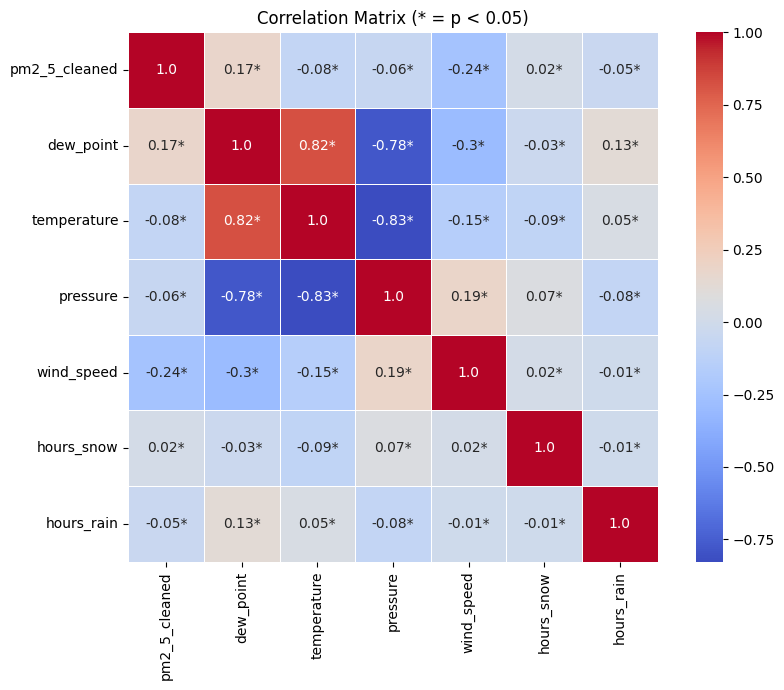

In [17]:
from itertools import combinations

num_cols = ['pm2_5_cleaned', 'dew_point', 'temperature', 'pressure', 'wind_speed', 'hours_snow', 'hours_rain']
corr_matrix = df[num_cols].corr()

# Build significance mask
p_matrix = pd.DataFrame(np.ones((len(num_cols), len(num_cols))), columns=num_cols, index=num_cols)
for c1, c2 in combinations(num_cols, 2):
    clean = df[[c1, c2]].dropna()
    _, p = pearsonr(clean[c1], clean[c2])
    p_matrix.loc[c1, c2] = p
    p_matrix.loc[c2, c1] = p

annot = corr_matrix.round(2).astype(str)
for c1 in num_cols:
    for c2 in num_cols:
        if p_matrix.loc[c1, c2] < 0.05 and c1 != c2:
            annot.loc[c1, c2] += '*'

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=annot, fmt='', cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Correlation Matrix (* = p < 0.05)')
plt.tight_layout()
plt.savefig('stat4_correlation_matrix.png', dpi=150)
plt.show()